In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Configuration and paths
min_range = -0
max_range = +500

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""delta_score""","""#00A99D""","""SpliceAI""",1
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
variant_class = "intronic"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

anno = (
    anno
    .filter(
        filter_expression &
        (pl.col('consequence_splice_acceptor_variant') == 0) & (pl.col('consequence_splice_donor_variant') == 0) &
        # (pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1) &
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range)

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

am_pathogenicity,loftee_hc,region,Strand,delta_score,cadd_raw,gene_name,gpn_score,id,verphylop,gene_length,mamphylop,abexp_min,dist_to_tss,esmscoremissense,pangolin_score,absplice_dna_max,gpn_star_llr_calibrated_mean,TSS,promoterai_abs,absplice2_max
f32,i8,str,cat,f32,f32,str,f32,str,f32,i64,f32,f64,i64,f32,f32,f32,f64,i64,f32,f32
0.0,0,"""ENSG00000081479""","""-""",0.0,0.466688,"""LRP2""",-1.5,"""chr2:169197167:T:G""",0.217,235427,0.774,-0.006063,165367,0.0,0.0,0.001,0.153293,169362534,0.0,0.000033
0.0,0,"""ENSG00000081479""","""-""",0.01,0.104863,"""LRP2""",-0.63,"""chr2:169204292:A:T""",0.291,235427,0.085,-0.026342,158242,0.0,0.0,0.003,1.684965,169362534,0.0,0.000116
0.0,0,"""ENSG00000073734""","""-""",0.0,0.326902,"""ABCB11""",-1.64,"""chr2:169030531:C:T""",0.023,115828,0.015,-0.005501,793,0.0,0.0,0.001,-1.212965,169031324,0.0,0.000033
0.0,0,"""ENSG00000073734""","""-""",0.0,-0.070862,"""ABCB11""",0.08,"""chr2:169007174:C:T""",0.193,115828,0.19,-0.005501,24150,0.0,0.0,0.001,-0.238119,169031324,0.0,0.000033
0.0,0,"""ENSG00000081479""","""-""",0.0,0.211538,"""LRP2""",-0.98,"""chr2:169175752:G:A""",0.117,235427,0.117,-0.006358,186782,0.0,0.0,0.001,-1.768037,169362534,0.0,0.000033
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0,"""ENSG00000091972""","""+""",0.0,-0.577349,"""CD200""",1.12,"""chr3:112365432:T:C""",-1.497,30467,-1.553,null,33086,0.0,0.0,0.0,0.631638,112332346,0.0,0.0
0.0,0,"""ENSG00000091972""","""+""",0.0,0.73253,"""CD200""",-4.13,"""chr3:112330089:T:G""",-0.052,30467,-0.073,null,-2257,0.0,0.0,0.0,0.406711,112332346,0.0,0.0
0.0,0,"""ENSG00000091972""","""+""",0.0,0.636473,"""CD200""",-1.89,"""chr3:112329326:T:C""",0.407,30467,0.392,null,-3020,0.0,0.0,0.0,-1.380881,112332346,0.0,0.0


In [4]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr2:169197167:T:G""","""ENSG00000081479""","""loftee_hc""",0.0
"""chr2:169204292:A:T""","""ENSG00000081479""","""loftee_hc""",0.0
"""chr2:169030531:C:T""","""ENSG00000073734""","""loftee_hc""",0.0
"""chr2:169007174:C:T""","""ENSG00000073734""","""loftee_hc""",0.0
"""chr2:169175752:G:A""","""ENSG00000081479""","""loftee_hc""",0.0
…,…,…,…
"""chr3:112365432:T:C""","""ENSG00000091972""","""abexp_min""",null
"""chr3:112330089:T:G""","""ENSG00000091972""","""abexp_min""",null
"""chr3:112329326:T:C""","""ENSG00000091972""","""abexp_min""",null


In [5]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = appv.join(
    anno_keys, on='id', how='semi'
).filter(
    pl.col('n_individuals') <= mac
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [6]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [7]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(352, 1176)

In [8]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    # .drop_nulls() # FIXME: Was I droppping the variants with one individual?
    
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
    .filter(pl.col("n_variants") > 2)  # Filter for groups with more than 2 variants
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')

# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    correlation_df
    .join(
        anno_config_df, on='annotation'
    )
    .join(
        gene_trait_df[['region', 'phenotype', 'corr_dir']], on=['region', 'phenotype']
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('corr_dir')*pl.col('annotation_dir')
    )
)
print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Executing the full lazy plan with the streaming engine...
Final DataFrame shape: (16030, 12)


region,gene_name,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_dir,corr_beta
str,str,str,str,u64,f64,str,str,str,i64,f64,f64
"""ENSG00000163554""","""SPTA1""","""glycated_haemoglobin_hba1c_int""","""gpn_star_llr_calibrated_mean""",15757,0.004899,"""conservation""","""#942c80""","""GPN-Star""",-1,-1.0,0.004899
"""ENSG00000081052""","""COL4A4""","""haematocrit_percentage_int""","""loftee_hc""",32171,NaN,"""plof""","""#1f77b4""","""LOFTEE HC""",1,-1.0,NaN
"""ENSG00000240505""","""TNFRSF13B""","""platelet_crit_int""","""pangolin_score""",7411,-0.001506,"""splicing""","""#20c997""","""Pangolin""",1,-1.0,0.001506
"""ENSG00000072274""","""TFRC""","""red_blood_cell_erythrocyte_cou…","""gpn_star_llr_calibrated_mean""",16891,0.00005,"""conservation""","""#942c80""","""GPN-Star""",-1,1.0,-0.00005
"""ENSG00000066827""","""ZFAT""","""standing_height_int""","""esmscoremissense""",51887,NaN,"""missense""","""#feb72d""","""ESM1v""",-1,1.0,NaN
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000120053""","""GOT1""","""aspartate_aminotransferase_int""","""delta_score""",6456,0.009833,"""splicing""","""#00A99D""","""SpliceAI""",1,-1.0,-0.009833
"""ENSG00000084674""","""APOB""","""alanine_aminotransferase_int""","""absplice2_max""",6346,0.038271,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1,1.0,0.038271
"""ENSG00000138688""","""KIAA1109""","""leg_fat_mass_right_int""","""verphylop""",38227,-0.003993,"""conservation""","""#6a1c81""","""Vertebrate PhyloP""",1,1.0,-0.003993


In [15]:
# filt_corr_df = correlation_df.filter(~pl.col('category').is_in(['regulatory', 'plof', 'naive', 'missense']))
# filt_corr_df = correlation_df.filter(~pl.col('category').is_in(['plof', 'naive', 'missense', 'regulatory']))
filt_corr_df = correlation_df.filter(pl.col('category').is_in(['splicing', 'genetic_diversity', 'conservation']))

consistent_gt = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'gene_name', 'phenotype'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == filt_corr_df['annotation'].n_unique())
)

filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'gene_name', 'phenotype'], how='inner')
filt_corr_df

region,gene_name,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_dir,corr_beta,n_annotations
str,str,str,str,u64,f64,str,str,str,i64,f64,f64,u64
"""ENSG00000163554""","""SPTA1""","""glycated_haemoglobin_hba1c_int""","""gpn_star_llr_calibrated_mean""",15757,0.004899,"""conservation""","""#942c80""","""GPN-Star""",-1,-1.0,0.004899,9
"""ENSG00000240505""","""TNFRSF13B""","""platelet_crit_int""","""pangolin_score""",7411,-0.001506,"""splicing""","""#20c997""","""Pangolin""",1,-1.0,0.001506,9
"""ENSG00000072274""","""TFRC""","""red_blood_cell_erythrocyte_cou…","""gpn_star_llr_calibrated_mean""",16891,0.00005,"""conservation""","""#942c80""","""GPN-Star""",-1,1.0,-0.00005,9
"""ENSG00000197891""","""SLC22A12""","""urate_int""","""gpn_star_llr_calibrated_mean""",1473,0.014912,"""conservation""","""#942c80""","""GPN-Star""",-1,-1.0,0.014912,9
"""ENSG00000196739""","""COL27A1""","""trunk_fatfree_mass_int""","""pangolin_score""",32073,0.003089,"""splicing""","""#20c997""","""Pangolin""",1,-1.0,-0.003089,9
…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000100031""","""GGT1""","""gamma_glutamyltransferase_int""","""pangolin_score""",5667,-0.030558,"""splicing""","""#20c997""","""Pangolin""",1,-1.0,0.030558,9
"""ENSG00000120053""","""GOT1""","""aspartate_aminotransferase_int""","""delta_score""",6456,0.009833,"""splicing""","""#00A99D""","""SpliceAI""",1,-1.0,-0.009833,9
"""ENSG00000084674""","""APOB""","""alanine_aminotransferase_int""","""absplice2_max""",6346,0.038271,"""splicing""","""#1E8449""","""AbSplice2 (max)""",1,1.0,0.038271,9


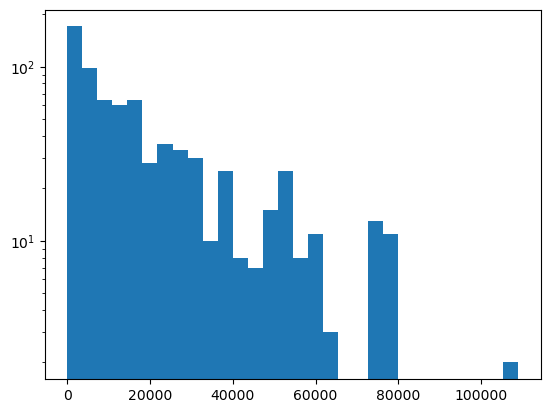

In [16]:
# filt_corr_df[['gene_name', 'n_variants']].unique()['n_variants'].describe()
plt.hist(filt_corr_df[['gene_name', 'n_variants']].unique()['n_variants'], bins=30, log=True)
plt.show()

In [17]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


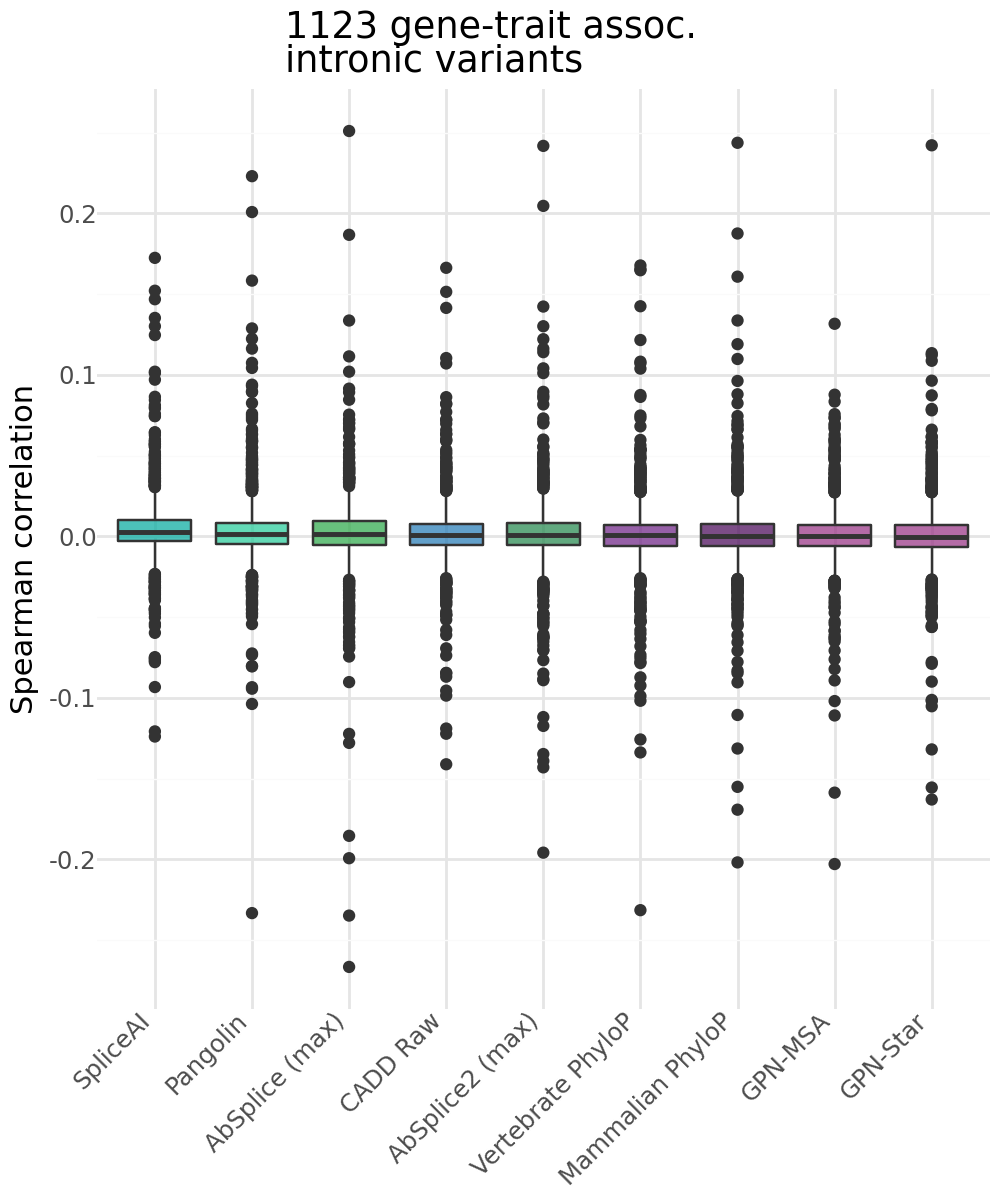

In [18]:
# Prepare for plotting
med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta = pl.col("corr_beta").median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=False)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation")) +
    geom_boxplot(alpha=0.7) +
    theme_minimal() +
    scale_fill_manual(values=color_dict) +
    labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc. \
        \n{variant_class} variants"
        # \nGene body ±10kb"
        # \n[{min_range}bp, {max_range}bp]"
    ) +
    theme(
        figure_size=(5, 6),
        legend_position="none",
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [19]:
med_df.sort('median_corr_beta')

annotation,median_corr_beta
str,f64
"""gpn_star_llr_calibrated_mean""",-0.000404
"""gpn_score""",0.000077
"""mamphylop""",0.000329
"""verphylop""",0.000613
"""absplice2_max""",0.000849
"""cadd_raw""",0.00096
"""absplice_dna_max""",0.001293
"""pangolin_score""",0.001379
"""delta_score""",0.002743


In [20]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_250266/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""gpn_star_llr_calibrated_mean""","""delta_score""",1123,240457.0,4.8860e-12
"""verphylop""","""delta_score""",1123,241538.0,9.8000e-12
"""delta_score""","""gpn_score""",1123,241710.0,1.0938e-11
"""absplice2_max""","""delta_score""",1123,243569.0,3.5298e-11
"""mamphylop""","""delta_score""",1123,246413.0,2.0049e-10
…,…,…,…,…
"""gpn_star_llr_calibrated_mean""","""cadd_raw""",1123,287293.0,0.009309
"""absplice_dna_max""","""gpn_score""",1123,289719.0,0.017438
"""cadd_raw""","""verphylop""",1123,290323.0,0.020245


## Odds ratio plot

In [46]:
correlation_df.filter(pl.col('n_variants')>100)
# pos_corr_df.filter(pl.col('n_variants')>100)

region,gene_name,phenotype,annotation,n_variants,correlation,abs_corr,beta,beta_dir,annotation_dir,color,label,corr_beta
str,str,str,str,u64,f64,f64,f64,f64,i64,str,str,f64
"""ENSG00000168140""","""VASN""","""alkaline_phosphatase_int""","""gpn_score""",260,0.098816,0.098816,0.0734599,1.0,-1,"""#942c80""","""GPN-MSA""",-0.098816
"""ENSG00000112343""","""TRIM38""","""mean_corpuscular_volume_int""","""verphylop""",136,0.185549,0.185549,-0.055847,-1.0,1,"""#440154""","""Vertebrate PhyloP""",-0.185549
"""ENSG00000112077""","""RHAG""","""high_light_scatter_reticulocyt…","""relative_cds_position""",106,0.175081,0.175081,0.73951,1.0,-1,"""#b5de2b""","""Relative CDS Position""",-0.175081
"""ENSG00000104044""","""OCA2""","""age_started_wearing_glasses_or…","""esmscoremissense""",258,0.120421,0.120421,-0.116217,-1.0,-1,"""#feb72d""","""ESM1v""",0.120421
"""ENSG00000117400""","""MPL""","""mean_platelet_thrombocyte_volu…","""zooverphylop""",159,0.014906,0.014906,-0.125828,-1.0,1,"""#6a1c81""","""Zoonomia vertebrate PhyloP""",-0.014906
"""ENSG00000204469""","""PRRC2A""","""platelet_distribution_width_in…","""cadd_raw""",761,-0.06714,0.06714,-0.076719,-1.0,1,"""#1f77b4""","""CADD Raw""",0.06714
"""ENSG00000165702""","""GFI1B""","""eosinophill_count_int""","""am_pathogenicity""",108,0.100956,0.100956,0.487639,1.0,1,"""#e76e5b""","""AlphaMissense""",0.100956
"""ENSG00000080031""","""PTPRH""","""reticulocyte_percentage_int""","""esmscoremissense""",357,0.017339,0.017339,-0.032778,-1.0,-1,"""#feb72d""","""ESM1v""",0.017339
…,…,…,…,…,…,…,…,…,…,…,…,…


In [ ]:
pos_pheno_anno = pheno_anno.join(pos_gene_trait, on=['gene_name', 'phenotype'], how='inner')

ct_df = pos_pheno_anno.group_by(
    ["region", "gene_name", "phenotype", "annotation"]
).agg(
    pl.col("id").count().alias("n_variants"),
).join(
    gene_trait_df[['region', 'phenotype', 'beta', 'beta_dir']], on=['region', 'phenotype']
).join(
    anno_config_df, on='annotation'
)

xtm_df = pos_pheno_anno.join(ct_df, on=["region", "gene_name", "phenotype", "annotation"], how="left")


xtm_df = xtm_df.with_columns(
    (pl.col("mean_pheno_value") * pl.col("beta_dir")).alias("mean_pheno_value_dircrtd"),
    (pl.col("annotation_score")*pl.col("annotation_dir")).alias("annotation_score_dircrtd")
)

# Rank the mean phenotype values and annotation scores
rank_expressions = [
    pl.col(c)
    .rank("ordinal")
    .over(["region", "phenotype", "annotation"])
    .alias(f"{c}_rank")
    for c in ['mean_pheno_value_dircrtd', 'annotation_score_dircrtd']
]

# Apply the window expressions with .with_columns()
xtm_df = xtm_df.with_columns(rank_expressions).with_columns(
    (pl.col("mean_pheno_value_dircrtd_rank") / pl.col("n_variants")).alias("mean_pheno_value_dircrtd_ptile"),
    (pl.col("annotation_score_dircrtd_rank") / pl.col("n_variants")).alias("annotation_score_dircrtd_ptile")
)

xtm_df = xtm_df.with_columns(
    pl.when(pl.col("mean_pheno_value_dircrtd_ptile") >= 0.95)
    .then(1)
    .otherwise(0)
    .alias("mean_pheno_value_dircrtd_binary"),
)

xtm_df

In [ ]:
or_df_list = []
for p_itr in tqdm(range(100)):
    ptile_cutoff = 0.5 + p_itr/200
    # ptile_cutoff = p_itr/100

    or_temp = xtm_df.group_by(
        ["annotation", "region", "phenotype"]
    ).agg(
        ((pl.col("mean_pheno_value_dircrtd_binary")==1) & (pl.col("annotation_score_dircrtd_ptile")>=ptile_cutoff)).sum().alias("n_dis_above_cutoff"),
        ((pl.col("mean_pheno_value_dircrtd_binary")==0) & (pl.col("annotation_score_dircrtd_ptile")>=ptile_cutoff)).sum().alias("n_not_dis_above_cutoff"),
        (pl.col("mean_pheno_value_dircrtd_binary")==1).sum().alias("total_dis"),
        (pl.col("mean_pheno_value_dircrtd_binary")==0).sum().alias("total_not_dis")
    ).with_columns(
        pl.lit(ptile_cutoff).alias("ptile_cutoff"),
        (pl.col("total_dis")+pl.col("total_not_dis")).alias("n_variants"),
        (((pl.col("n_dis_above_cutoff")+1) / (pl.col("n_not_dis_above_cutoff")+1))/(pl.col("total_dis")/pl.col("total_not_dis"))).alias("odds_ratio"),
    )

    or_df_list.append(or_temp)

or_df = pl.concat(or_df_list)
or_df

In [ ]:
plot_df = or_df.group_by(
    ['annotation', 'ptile_cutoff']
).agg(
    pl.col('odds_ratio').mean()
)

(
    ggplot(plot_df, aes(x='ptile_cutoff', y='odds_ratio', color='annotation')) +
    geom_line(size=1.25) +
    theme_minimal() +
    scale_y_log10() +
    # scale_x_log10() +
    scale_color_manual(values=color_dict) +
    labs(
        x='Percentile Cutoff',
        y='Average Odds Ratio'
    ) +
    theme(
        figure_size=(6, 4),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)